In [1]:
%pip install -e ..

Obtaining file:///cluster/home/adelez/BOREAL-FOREST-EXPANSION
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for boreal-forest-expansion (pyproject.toml) ... done
  Created wheel for boreal-forest-expansion: filename=boreal_forest_expansion-0.1.0-0.editable-py3-none-any.whl size=3019 sha256=90ed1a27e68b15a5f6635f671167d51a872ad74080056917508cc2e87fefd4f1
  Stored in directory: /tmp/pip-ephem-wheel-cache-_11usjl1/wheels/33/36/1f/1eb3d87ab90ac9df0155d6c5260fbf518d629b608d8b09c675
Successfully built boreal-forest-expansion
  Attempting uninstall: boreal-forest-expansion
    Found existing installation: boreal-forest-expansion 0.1.0
    Uninstalling boreal-forest-expansion-0.1.0:
      Successfully uninstalled boreal-forest-expansion-0.1.0
Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path

import xarray as xr
import matplotlib.pyplot as plt

from boreal_forest_expansion.plotting.style import set_default_style
from boreal_forest_expansion.plotting.forcing_maps import (
    POSTPROCESSED_DIR,
    FIGURE_DIR,
    make_forcing_summary_figure,
    make_context_maps_figure,
    difference_map,
    BVOC_PAIRS,
)

set_default_style()

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/cluster/home/adelez/.pyenv-cartopy/lib64/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/cluster/home/adelez/.pyenv-cartopy/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/cluster/home/adelez/.pyenv-cartopy/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/cluster/home/adelez/.pyenv-cartopy/lib64/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/cluster/home/adelez/.pyenv-cartopy/lib64/python3.9/site-packages/traitlets/traitlets.py", line 649, i

In [2]:
START_YEAR = 2001
END_YEAR = 2009

POSTPROCESSED_DIR

# Check files exist
expected = [
    f"CTRL_RADIATIVE_{START_YEAR}_{END_YEAR}.nc",
    f"LCC-PD_RADIATIVE_{START_YEAR}_{END_YEAR}.nc",
    f"LCC-PD-fBVOC_RADIATIVE_{START_YEAR}_{END_YEAR}.nc",
    f"LCC-FUT_RADIATIVE_{START_YEAR}_{END_YEAR}.nc",
    f"LCC-FUT-fBVOC_RADIATIVE_{START_YEAR}_{END_YEAR}.nc",
]

for fname in expected:
    path = POSTPROCESSED_DIR / fname
    print(path.name, "✓" if path.exists() else "MISSING")

CTRL_RADIATIVE_2001_2009.nc ✓
LCC-PD_RADIATIVE_2001_2009.nc ✓
LCC-PD-fBVOC_RADIATIVE_2001_2009.nc ✓
LCC-FUT_RADIATIVE_2001_2009.nc ✓
LCC-FUT-fBVOC_RADIATIVE_2001_2009.nc ✓


Saved /cluster/home/adelez/BOREAL-FOREST-EXPANSION/results/figures/PD_forcing_decomposition_2001_2009.png


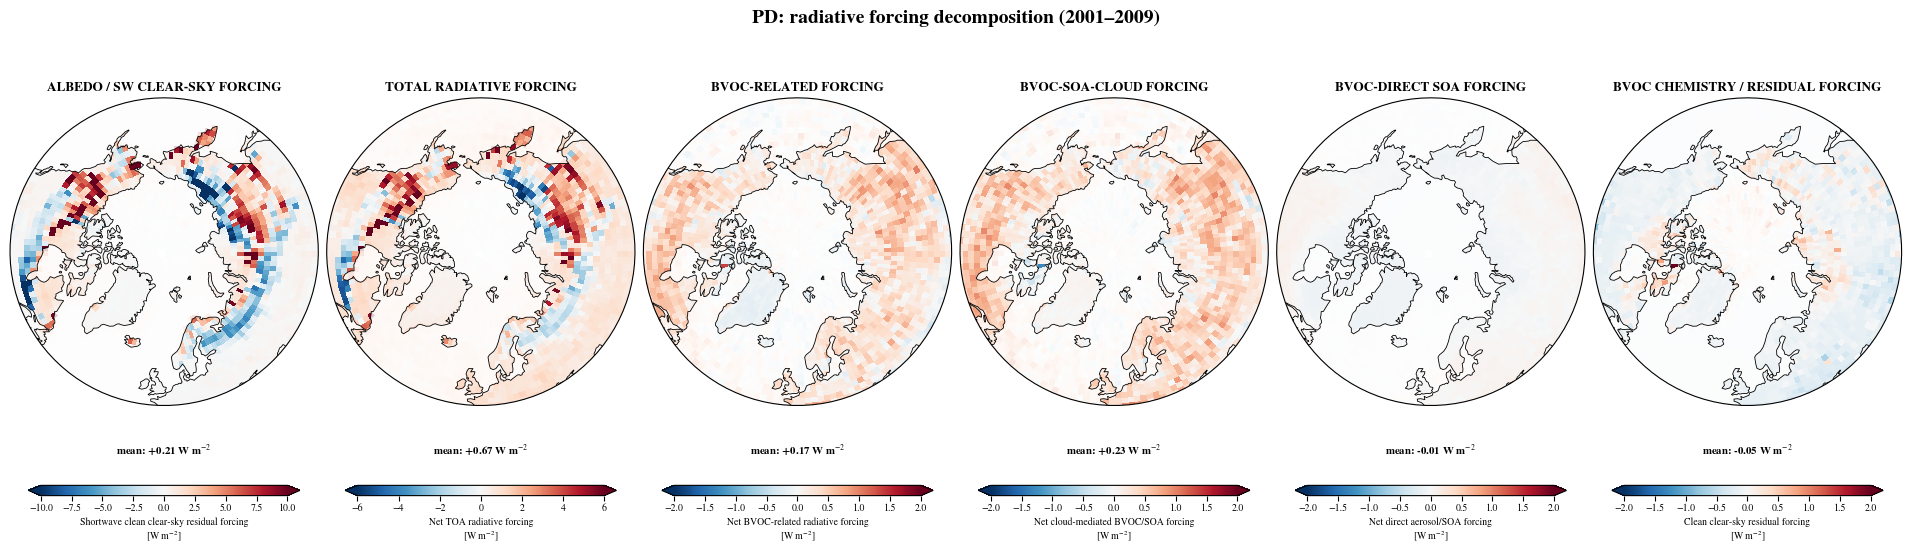

In [3]:
fig, axes = make_forcing_summary_figure(
    experiment="PD",
    start_year=START_YEAR,
    end_year=END_YEAR,
    extent_lat=45,
    mean_lat_min=45,
    save=True,
    add_cbar=True,
    shade_ocean=True,
    ocean_alpha=0.8,
    ocean_facecolor="white",
)

Saved /cluster/home/adelez/BOREAL-FOREST-EXPANSION/results/figures/FUT_forcing_decomposition_2001_2009.png


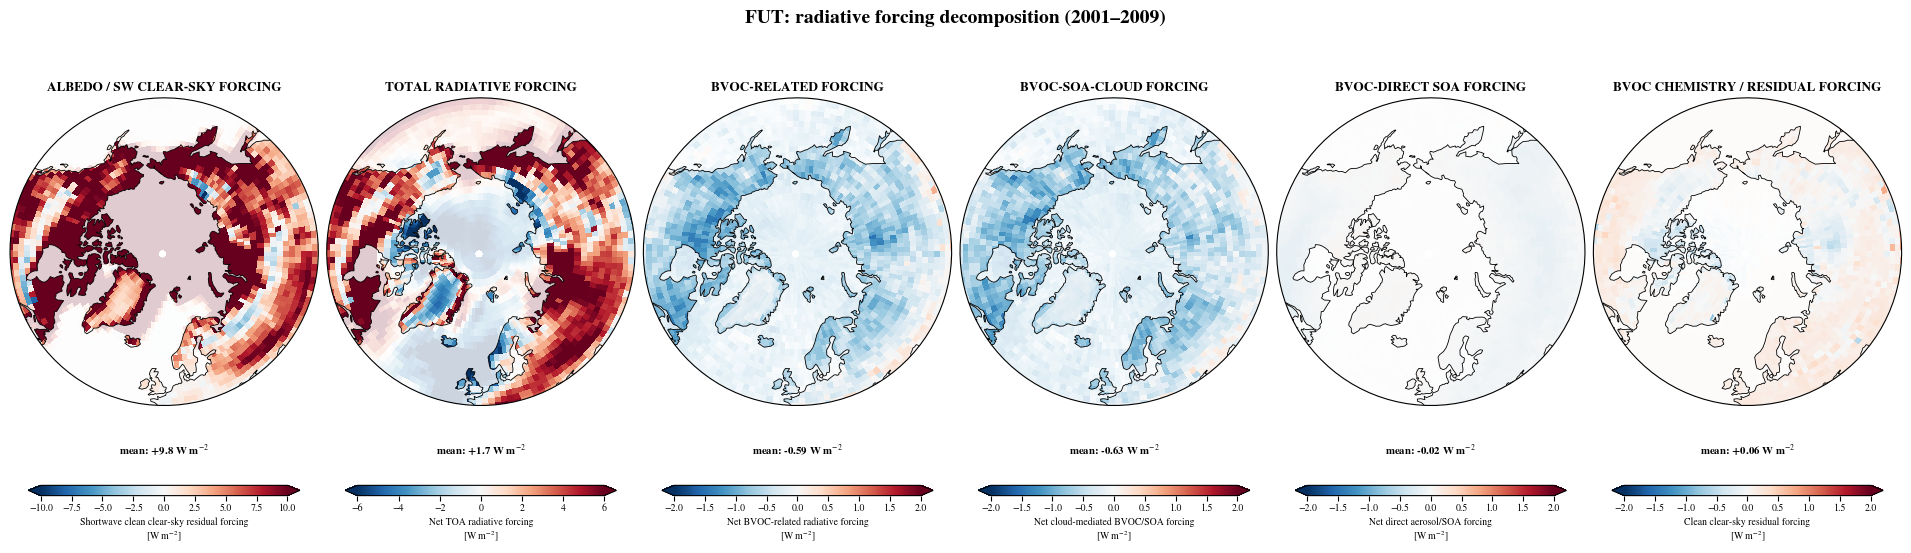

In [4]:
fig, axes = make_forcing_summary_figure(
    experiment="FUT",
    start_year=START_YEAR,
    end_year=END_YEAR,
    extent_lat=45,
    mean_lat_min=45,
    save=True,
    add_cbar=True,
    shade_ocean=True,
    ocean_alpha=0.8,
    ocean_facecolor="white",
)

## BVOC/SOA/cloud mechanism maps

Skipping soa_tot: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-PD_SOA_2001_2009.nc
Skipping n_aer: 'N_AER not found in /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-PD_AEROSOL_2001_2009.nc'
Skipping fctl: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-PD_CLOUDPROP_2001_2009.nc
Skipping actrel: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-PD_CLOUDPROP_2001_2009.nc
Skipping actnl: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-PD_CLOUDPROP_2001_2009.nc
Skipping lwp: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-PD_CLOUDPROP_2001_2009.nc
Skipping et: Missing postprocessed file: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostic

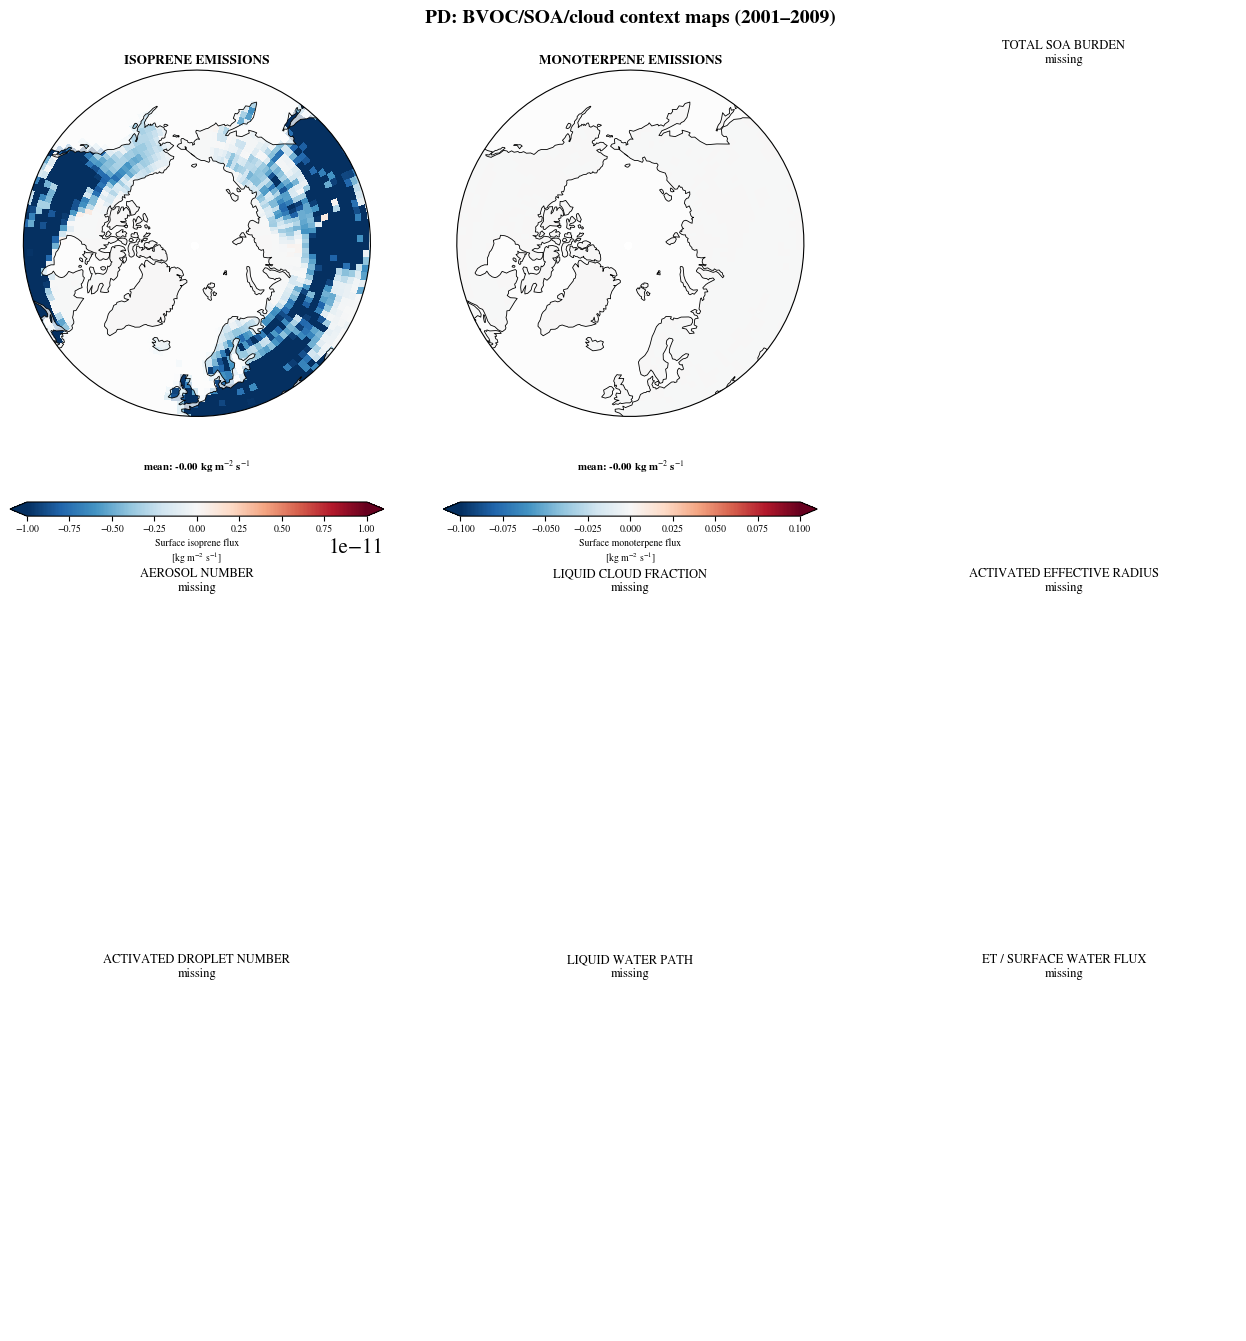

In [5]:
fig, axes = make_context_maps_figure(
    experiment="PD",
    start_year=START_YEAR,
    end_year=END_YEAR,
    extent_lat=45,
    mean_lat_min=45,
    save=True,
)

Skipping soa_tot: 'cb_SOA_TOT_mgm2 not found in /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-FUT_SOA_2001_2009.nc'
Skipping n_aer: 'N_AER not found in /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-FUT_AEROSOL_2001_2009.nc'
Skipping actrel: 'ACTREL_incld not found in /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-FUT_CLOUDPROP_2001_2009.nc'
Skipping actnl: 'ACTNL_incld not found in /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-FUT_CLOUDPROP_2001_2009.nc'
Skipping et: 'QFLX_mmday not found in /cluster/home/adelez/BOREAL-FOREST-EXPANSION/data/postprocessed-diagnostics/LCC-FUT_METEOROLOGY_2001_2009.nc'
Saved /cluster/home/adelez/BOREAL-FOREST-EXPANSION/results/figures/FUT_bvoc_context_maps_2001_2009.png


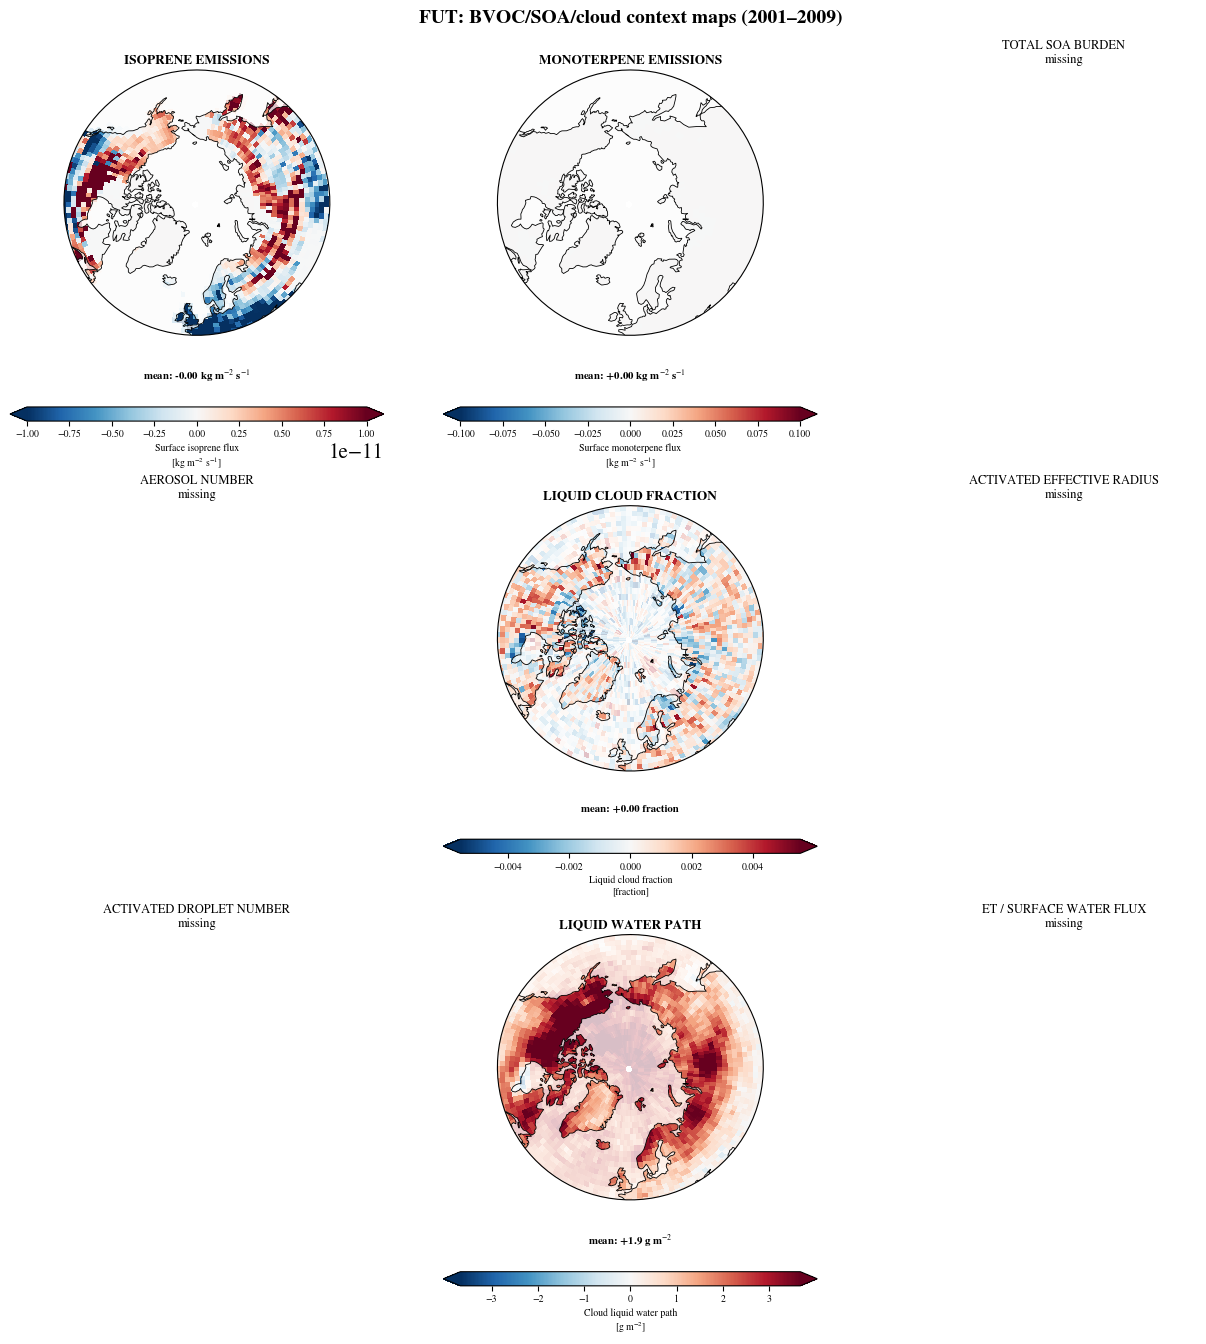

In [6]:
fig, axes = make_context_maps_figure(
    experiment="FUT",
    start_year=START_YEAR,
    end_year=END_YEAR,
    extent_lat=45,
    mean_lat_min=45,
    save=True,
)

In [7]:
da = difference_map(
    case1="LCC-PD",
    case2="LCC-PD-fBVOC",
    variable_class="RADIATIVE",
    variable="FTOT_Ghan",
    start_year=START_YEAR,
    end_year=END_YEAR,
)

da

<xarray.DataArray 'FTOT_Ghan_LCC-PD_minus_LCC-PD-fBVOC' (lat: 96, lon: 144)> Size: 111kB
array([[-0.1148121 , -0.1147297 , -0.11459782, ..., -0.11469648,
        -0.11479221, -0.1145573 ],
       [-0.10961047, -0.1006011 , -0.10447305, ..., -0.11392401,
        -0.11040433, -0.10506509],
       [-0.09936045, -0.10988912, -0.11318142, ..., -0.0953057 ,
        -0.09718395, -0.09437999],
       ...,
       [-0.00825997,  0.00819204,  0.07790688, ..., -0.15468417,
        -0.14519541, -0.06202422],
       [-0.11673677, -0.04240106, -0.07395376, ..., -0.14570858,
        -0.10626193, -0.19961731],
       [ 0.08673254,  0.08718579,  0.08668753, ...,  0.0851738 ,
         0.08578162,  0.0891616 ]])
Coordinates:
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    units:      
    long_name:  FTOT_Ghan: LCC-PD - LCC-PD-fBVOC

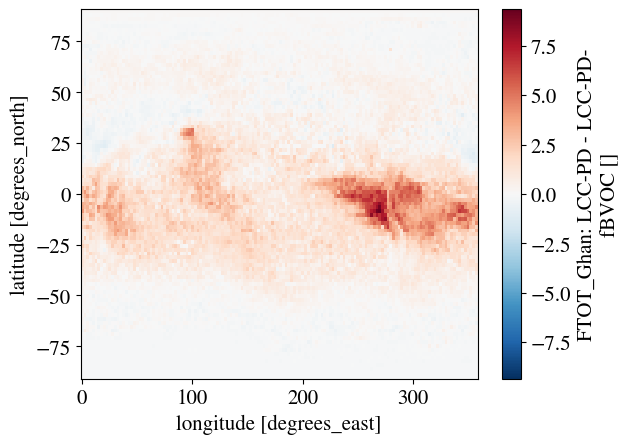

In [8]:
da.plot()